In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Imported Successfully")

Imported Successfully


In [11]:
#load data
data = pd.read_csv("Netflix_Dataset.csv")
print(data.head())

  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

        Release_Date Rating   Duration  \
0    August 14, 2020  TV-MA  4 Seasons   
1  December 23, 2016  TV-MA     93 min   
2  December 20, 2018      R     78 min   
3  November 16, 2017  PG-13     80 min   
4    January 1, 2020  PG-13    123 min   

                               

In [12]:
# Clean dataset
data = data.dropna(subset=['Director', 'Cast', 'Country', 'Release_Date', 'Rating', 'Duration', 'Type', 'Description'])

In [13]:
print(data)

     Show_Id Category       Title           Director  \
1         s2    Movie       07:19  Jorge Michel Grau   
2         s3    Movie       23:59       Gilbert Chan   
3         s4    Movie           9        Shane Acker   
4         s5    Movie          21     Robert Luketic   
5         s6  TV Show          46        Serdar Akar   
...      ...      ...         ...                ...   
7780   s7779    Movie  Zombieland    Ruben Fleischer   
7782   s7781    Movie         Zoo       Shlok Sharma   
7783   s7782    Movie        Zoom       Peter Hewitt   
7784   s7783    Movie        Zozo        Josef Fares   
7785   s7784    Movie      Zubaan        Mozez Singh   

                                                   Cast  \
1     Demián Bichir, Héctor Bonilla, Oscar Serrano, ...   
2     Tedd Chan, Stella Chung, Henley Hii, Lawrence ...   
3     Elijah Wood, John C. Reilly, Jennifer Connelly...   
4     Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...   
5     Erdal Beşikçioğlu, Yasemin

In [19]:
count_type = data["Category"].value_counts()
print(count_type)

Category
Movie      4675
TV Show     136
Name: count, dtype: int64


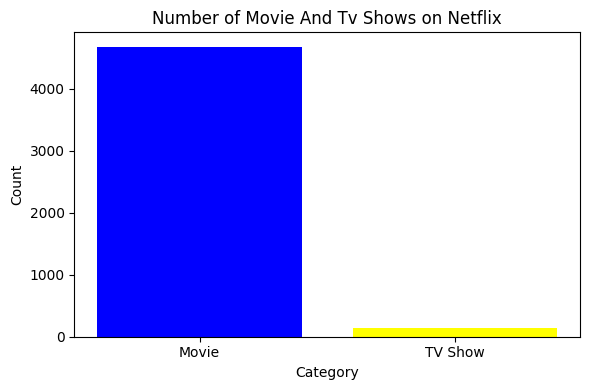

In [32]:
# Movie VS Tv Shows
plt.figure(figsize=(6,4))
plt.bar(count_type.index, count_type.values, color=['blue','yellow'])
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Number of Movie And Tv Shows on Netflix")
plt.tight_layout()
#plt.savefig("movie_tvShows.png", dpi=300)
plt.show()

In [33]:
#Rating Percentage
rating_counts = data["Rating"].value_counts()
print(rating_counts)

Rating
TV-MA       1668
TV-14       1133
R            654
TV-PG        413
PG-13        375
PG           238
TV-G          80
TV-Y          71
TV-Y7         69
NR            62
G             38
UR             5
TV-Y7-FV       3
NC-17          2
Name: count, dtype: int64


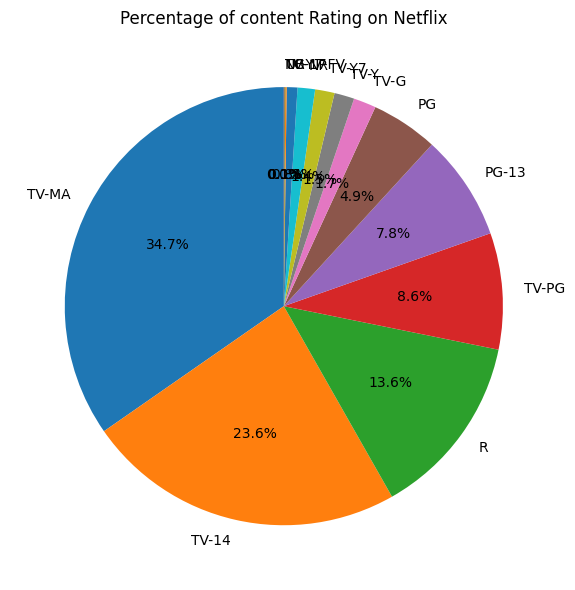

In [43]:
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Percentage of content Rating on Netflix")
#plt.savefig("content_rating.png")
plt.tight_layout()
plt.show()

In [50]:
#Duration Distribution of Movie
movie_data = data[data["Category"] == "Movie"].copy()
movie_data["duration_int"] = movie_data["Duration"].str.replace(" min","").astype(int)
print(movie_data.head())

  Show_Id Category  Title           Director  \
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   
6      s7    Movie    122    Yasir Al Yasiri   

                                                Cast        Country  \
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   
6  Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...          Egypt   

        Release_Date Rating Duration  \
1  December 23, 2016  TV-MA   93 min   
2  December 20, 2018      R   78 min   
3  November 16, 2017  PG-13   80 min   
4    January 1, 2020  PG-13  123 min   
6       June 1, 2020  TV-MA   95 min   

                                           

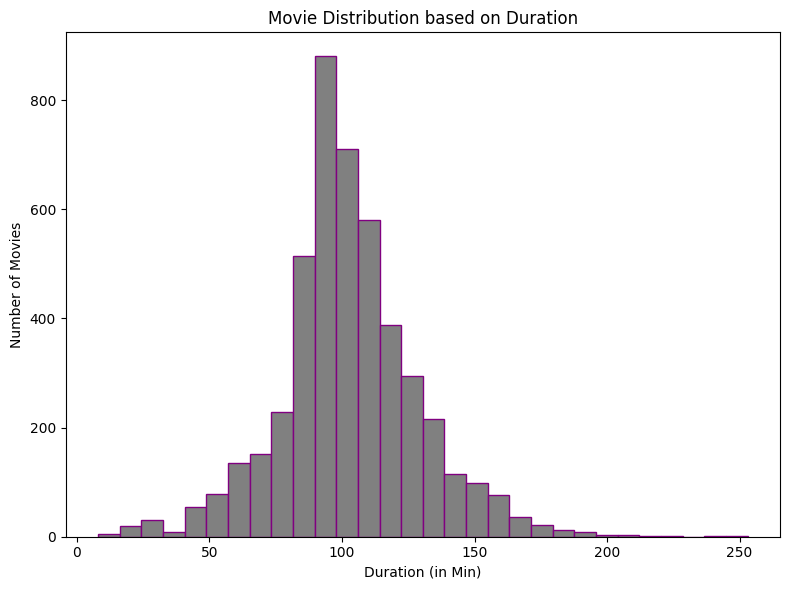

In [59]:
plt.figure(figsize=(8,6))
plt.hist(movie_data["duration_int"], bins=30, color='grey', edgecolor='purple')
plt.xlabel("Duration (in Min)")
plt.ylabel("Number of Movies")
plt.title('Movie Distribution based on Duration')
plt.tight_layout()
#plt.savefig("Time_distribution_of_movie.png")
plt.show()

In [95]:
#Relationship between releasing year and no.of movies
movie_data["Release_Year"] = movie_data["Release_Date"].str[-4:].astype(int)
#print(movie_data["Release_Year"].head())

movie_count_per_year = movie_data["Release_Year"].value_counts().sort_index()
print(movie_count_per_year.head())

Release_Year
2008     1
2009     2
2010     1
2011    13
2012     3
Name: count, dtype: int64


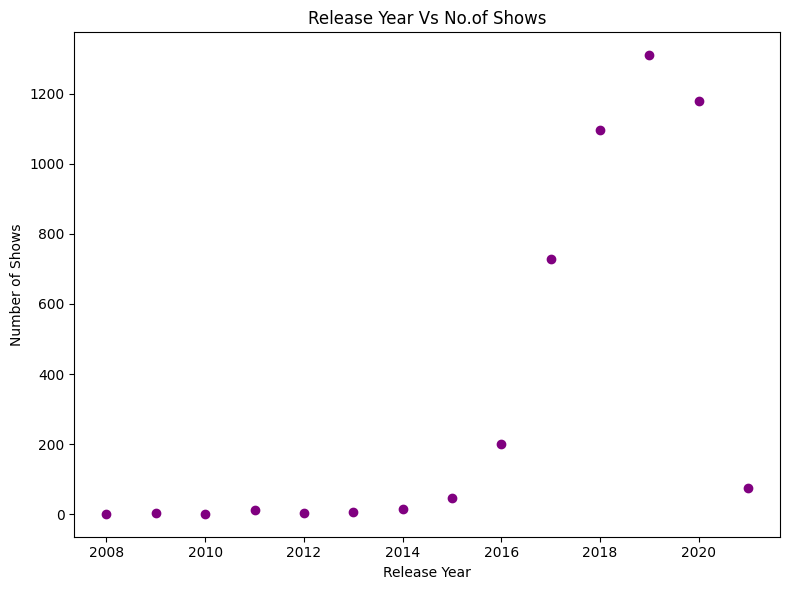

In [102]:
plt.figure(figsize=(8,6))
plt.scatter(movie_count_per_year.index, movie_count_per_year.values, color='purple')
plt.title("Release Year Vs No.of Shows")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.show()

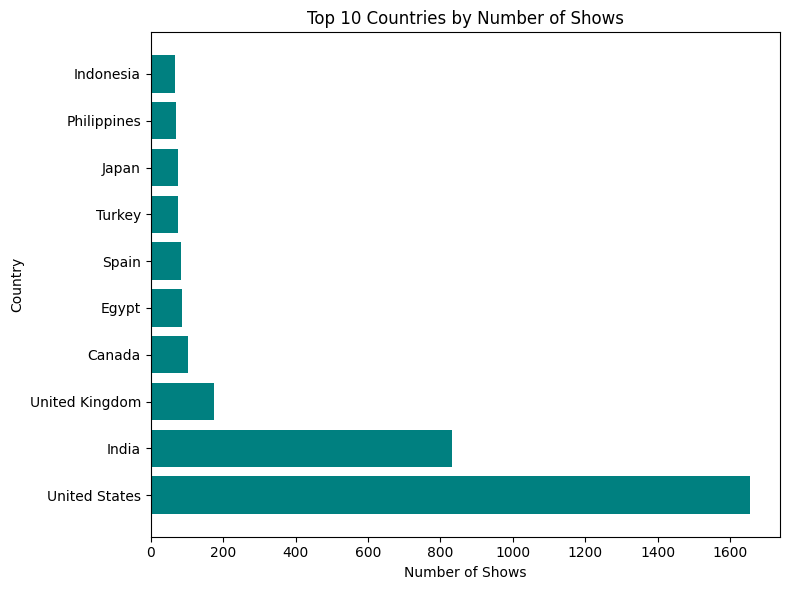

In [111]:
#Most release given by the country
country_count = data["Country"].value_counts().head(10)
#print(country_count)

plt.figure(figsize=(8,6))
plt.barh(country_count.index, country_count.values, color='teal')
plt.title("Top 10 Countries by Number of Shows")
plt.xlabel("Number of Shows")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [116]:
# Subplotting
data["Release_Year"] = data["Release_Date"].str[-4:].astype(int)
content_by_year = data.groupby(["Release_Year", "Category"]).size().unstack().fillna(0)
print(content_by_year.head())

Category      Movie  TV Show
Release_Year                
2008            1.0      0.0
2009            2.0      0.0
2010            1.0      0.0
2011           13.0      0.0
2012            3.0      0.0


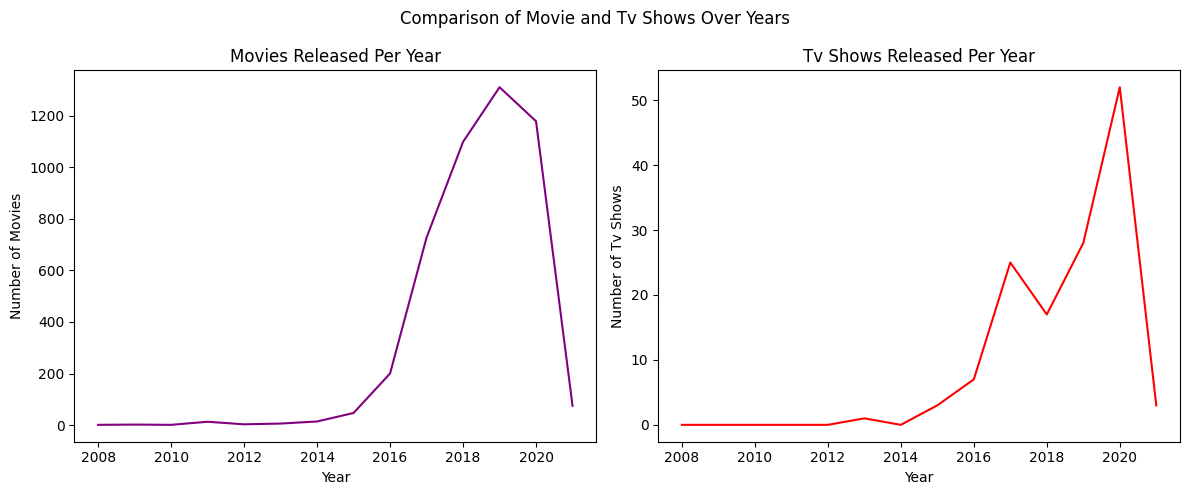

In [122]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

#Subplot- Movie
ax[0].plot(content_by_year.index, content_by_year.Movie, color='purple')
ax[0].set_title("Movies Released Per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of Movies")

#Subplot - Tv Shows
ax[1].plot(content_by_year.index, content_by_year["TV Show"], color='red')
ax[1].set_title("Tv Shows Released Per Year")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Number of Tv Shows")

fig.suptitle("Comparison of Movie and Tv Shows Over Years")
plt.tight_layout()
plt.show()